# Noise types TDV
```Authors: Paul Alvarez updated: 20261609```


El presente notebook explora diversos tipos de ruido aplicados en el proceso de $denoising$ de $\textbf{TDV}$. El algoritmo fue entrenado con imágenes del dataset BSDS400 degradas artificialmente mediante ruido guassiano ($\sigma = 25$). No obstante, en el campo del procesamiento de imágenes astronómicas el factor de ruido de las imágenes registradas viene modelado como una distribución Poisson, ya que implica el conteo discreto de los fotones registrados por sensores CCD. Por ello, el objetivo principal de este notebook es analizar el rendimiento de $\textbf{TDV}$ con la incportación de ruido ajeno al visto en el proceso de entrenamiento. 


In [ ]:
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)

In [88]:
# requeriments
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
from tdv.denoise_utils import apply_vn, check_color, denoise_z, load_model, psnr, test_img
from skimage.metrics import structural_similarity as ssim
from notebooks.utils import plot_results
from skimage import data, img_as_float


## Setup

In [89]:
# Load the image and checkpoint once
vn_color, checkpoint = load_model("color")
vn_color.eval()
img_path = os.path.join('..', 'data', 'water-castle.png')
img_01 = imageio.imread(img_path).astype(np.float32) / 255
y = img_01
images_to_test = {'water-castle': img_01}

In [ ]:
def test_noise(vn, y, noise, noise_params, images_to_test, gp= True, scaled=False, sigma_fixed=25, peak_fixed=100):
    results = {}

    """
    if gp true, g param is fixed and test p params  
    if gp false, p param is fixed and test g params 
    """

    for img_name, img_data in images_to_test.items():
        y, _ = check_color(np.asarray(img_data, dtype=np.float32))
        results[img_name] = {'x_psnr': [], 'z_psnr': [], 'x_ssim': [], 'z_ssim': [], 'images_by_param': {}}
        
        for param in noise_params:
            print(f"{img_name} | {noise} | param={param}: procesando...", flush=True)
            if noise=="gauss": z = add_gaussian_noise(y, sigma= param)
            if noise=="poisson": z = add_poisson_noise(y, peak= param)
            if noise=="salt pepper": z = add_salt_pepper_noise(y, prob= param)
            if noise=="gauss_poisson": 
                if gp: z = add_gp_noise(y, sigma=sigma_fixed, peak= param)
                else: z = add_gp_noise(y, sigma= param, peak=peak_fixed)

            sigma = param if noise == "gauss" or (noise == "gauss_poisson" and not gp) else sigma_fixed
            x = denoise_z(vn, z, sigma=sigma, scaled=scaled)
            c_axis = -1 if z.ndim == 3 else None

            current_x_psnr = psnr(x, y)
            current_z_psnr = psnr(z, y)
            current_x_ssim = ssim(x,y,data_range=1,channel_axis=c_axis)
            current_z_ssim = ssim(z,y,data_range=1,channel_axis=c_axis)
            results[img_name]['x_psnr'].append(current_x_psnr)
            results[img_name]['z_psnr'].append(current_z_psnr)
            results[img_name]['x_ssim'].append(current_x_ssim)
            results[img_name]['z_ssim'].append(current_z_ssim)
            
            results[img_name]['images_by_param'][param] = {'z': z, 'x': x, 'y': y  }
            print(f"Completado: PSNR={current_x_psnr:.2f} dB, SSIM={current_x_ssim:.4f}", flush=True)

    return results

In [91]:
def plot_noise_params(param, param_values, x_metric_param, z_metric_param=None, metric='PSNR', title=''):
    # Based on plot_hyperparams
    plt.figure(figsize=(12, 5))
    plt.plot(param_values, x_metric_param, 'o-', label=f'x_S {metric}')
    if z_metric_param is not None:
        plt.plot(param_values, z_metric_param, 'o--', color='gray', label=f'z {metric}')
    plt.title(f'{title} | {metric} v/s {param}')
    plt.xlabel(param)
    plt.ylabel('PSNR (dB)' if metric == 'PSNR' else metric)
    plt.xticks(param_values)
    plt.grid(True)
    plt.legend()
    plt.show()

## Gaussian noise

In [92]:
def add_gaussian_noise(img, sigma=25, max_value=255):
    y= img
    z = y + sigma / max_value * np.random.randn(*y.shape).astype(np.float32)
    return z

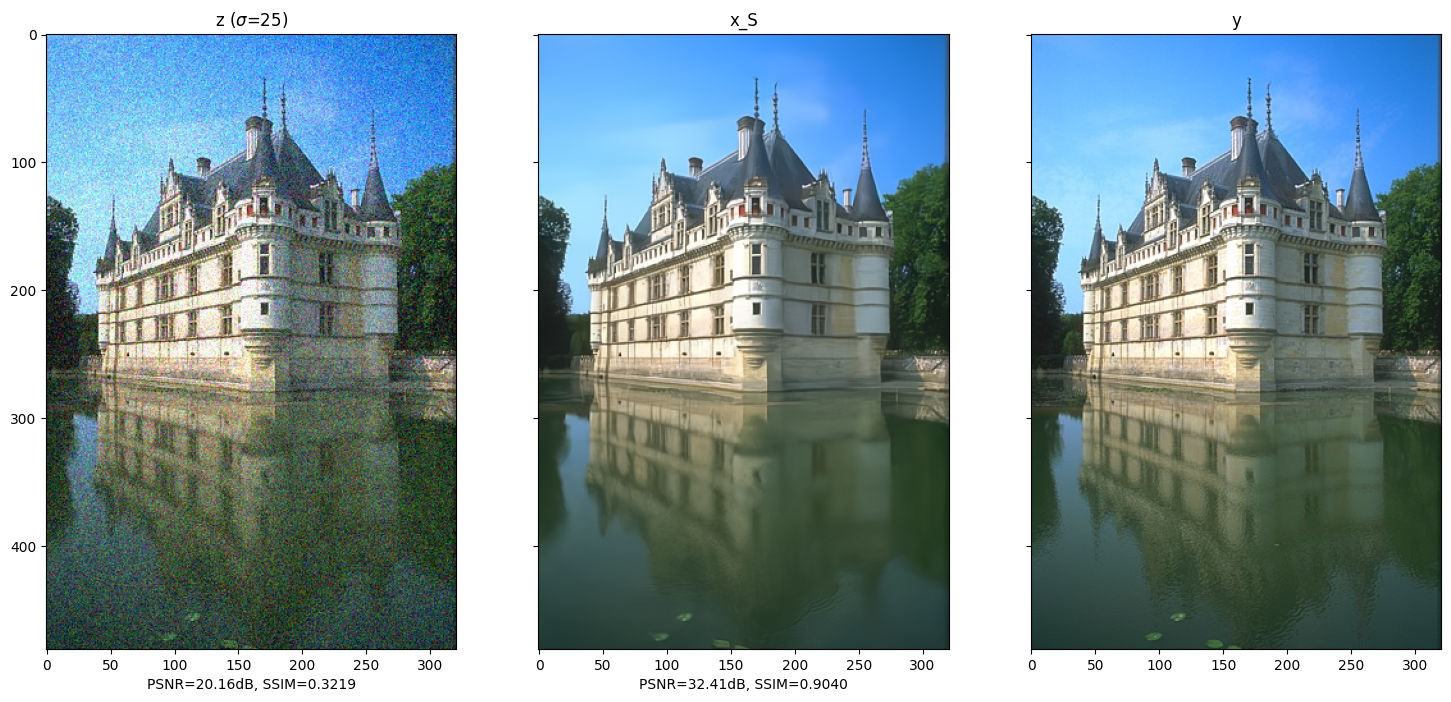

In [93]:
# test one image
z = add_gaussian_noise(y, sigma=25)
x = denoise_z(vn_color, z, sigma=25)
plot_results(z, x, y, sigma=25)

## Poisson noise

In [95]:
def add_poisson_noise(img, peak= 100):
    # add poisson noise by setting a max intensity (peak)
    poisson_noise = np.random.poisson(img * peak) 
    noisy_img = poisson_noise/peak 
    noisy_img  = noisy_img 
    noisy_img = np.clip(noisy_img, 0, 1)

    return noisy_img.astype(np.float32)

In [96]:
# TEST poisson noise values
peak_values = [1000, 100, 50, 25, 4]
results_poisson = test_noise(vn_color, y, "poisson", peak_values, images_to_test, scaled=False)

In [ ]:
# See results
img_target = 'water-castle'

for peak in peak_values:
    z = results_poisson[img_target]['images_by_param'][peak]['z']
    x = results_poisson[img_target]['images_by_param'][peak]['x']
    y_result = results_poisson[img_target]['images_by_param'][peak]['y']
    plot_results(z, x, y_result, peak=peak, figsize=(16, 10))


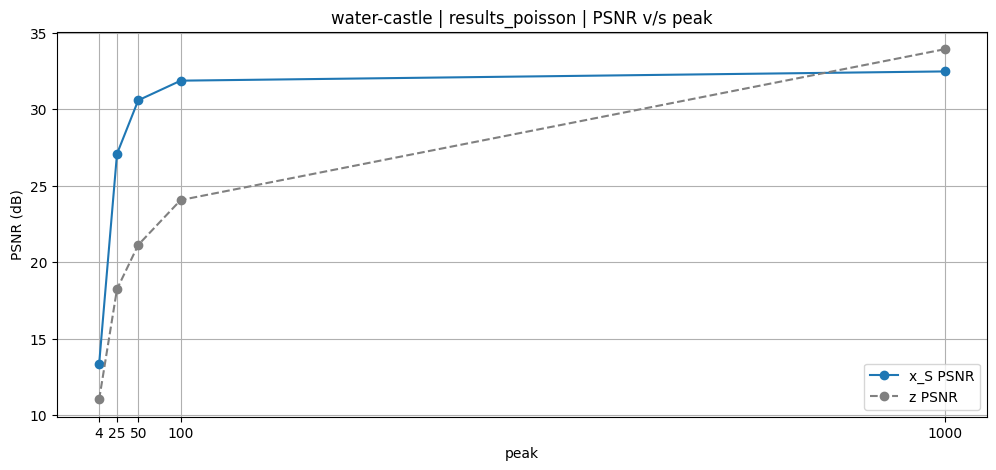

In [103]:
# Metrics for the same image and parameter values
img_target = 'water-castle'

for metric in ['psnr']: plot_noise_params(
        param='peak',
        param_values=peak_values,
        x_metric_param=results_poisson[img_target]['x_' + metric],
        z_metric_param=results_poisson[img_target]['z_' + metric],
        metric=metric.upper(),
        title=img_target + ' | results_poisson'
    )


## Salt and pepper noise

In [101]:
def add_salt_pepper_noise(img, prob = 0.5):
    output = img.copy()    
    black = np.float32(0.0)
    white = np.float32(1.0)
  
    probs = np.random.random(output.shape[:2])
    output[probs < (prob / 2)] = black
    output[probs > 1 - (prob / 2)] = white
  
    return output

### TDV-color

In [102]:
# test sp noise on color
prob_values = [0.001, 0.01, 0.05, 0.1]
results_salt_pepper_color = test_noise(vn_color, y, "salt pepper", prob_values, images_to_test, scaled=False)

In [ ]:
# See results
img_target = 'water-castle'

for prob in prob_values:
    z = results_salt_pepper_color[img_target]['images_by_param'][prob]['z']
    x = results_salt_pepper_color[img_target]['images_by_param'][prob]['x']
    y_result = results_salt_pepper_color[img_target]['images_by_param'][prob]['y']
    plot_results(z, x, y_result, prob=prob, figsize=(16, 10))


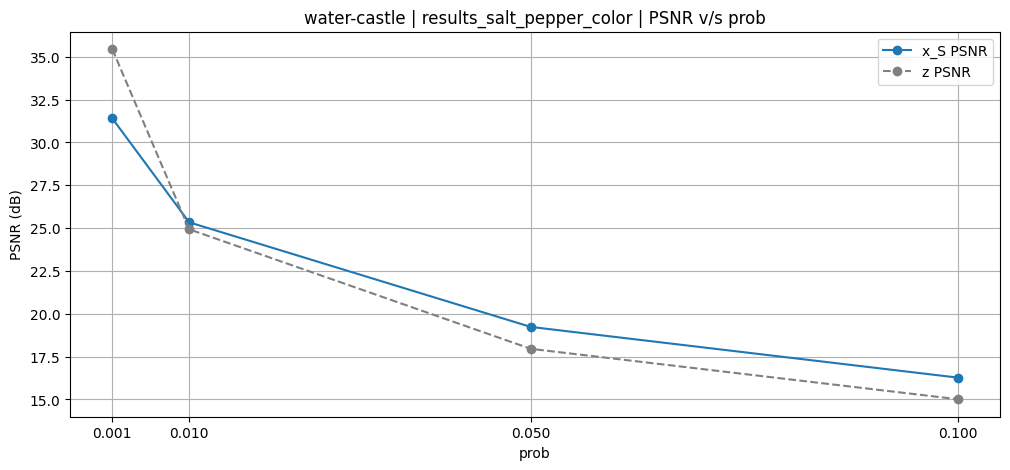

In [104]:
# Metrics for the same image and parameter values
for metric in ['psnr']: plot_noise_params(
        param='prob',
        param_values=prob_values,
        x_metric_param=results_salt_pepper_color[img_target]['x_' + metric],
        z_metric_param=results_salt_pepper_color[img_target]['z_' + metric],
        metric=metric.upper(),
        title=img_target + ' | results_salt_pepper_color'
    )


### TDV-gray

In [105]:
# load gray img
img_03 = img_as_float(data.camera())
_, color = check_color(img_03)
vn_gray, checkpoint = load_model(color)
images_to_test_gray = {'camera-man': img_03}

# test sp noise on black and white
results_salt_pepper_gray = test_noise(vn_gray, y, "salt pepper", prob_values, images_to_test_gray, scaled=False)

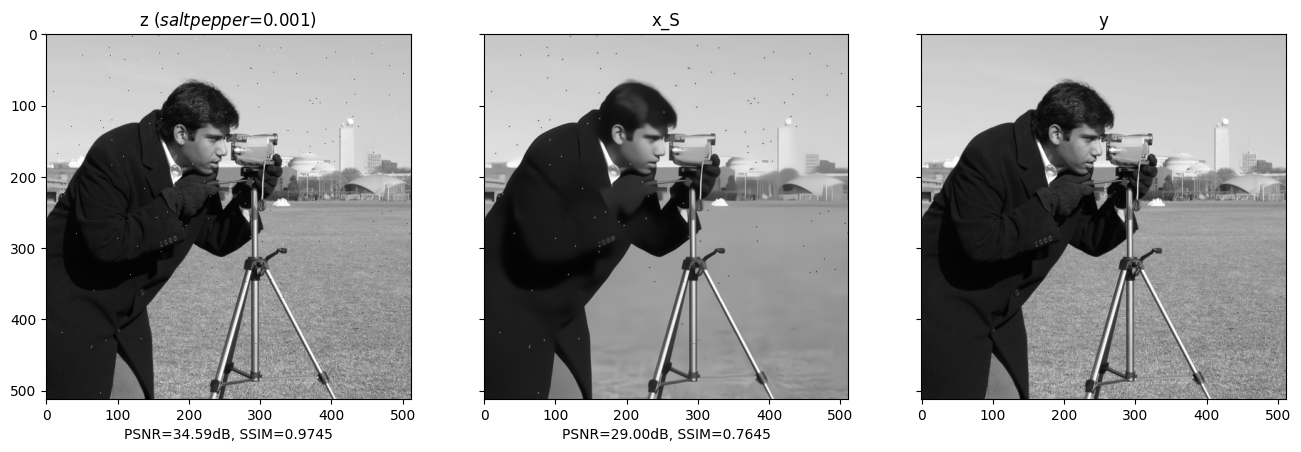

In [117]:
# See cached results
img_target_gray = 'camera-man'

for prob in prob_values[:1]:
    z = results_salt_pepper_gray[img_target_gray]['images_by_param'][prob]['z']
    x = results_salt_pepper_gray[img_target_gray]['images_by_param'][prob]['x']
    y_result = results_salt_pepper_gray[img_target_gray]['images_by_param'][prob]['y']
    plot_results(z, x, y_result, prob=prob, figsize=(16, 10))


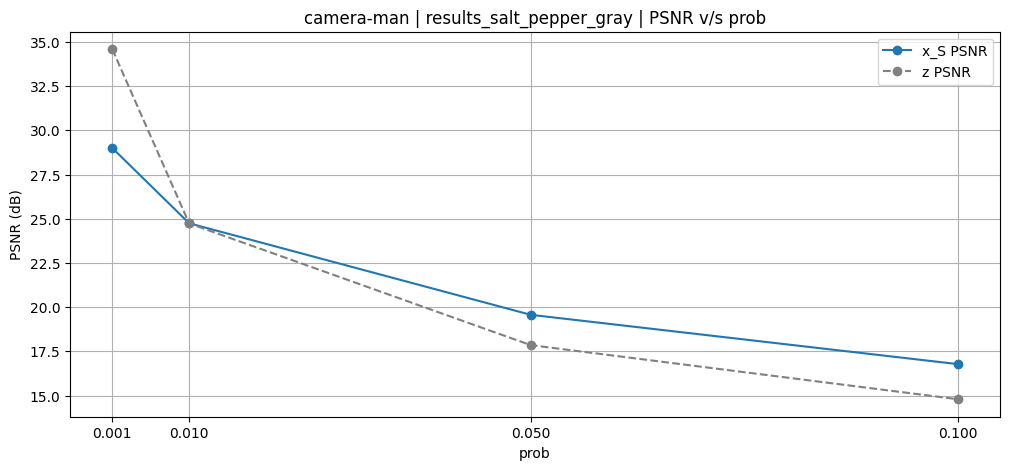

In [107]:
# Metrics for the same image and parameter values
img_target_gray = 'camera-man'

for metric in ['psnr']:
    plot_noise_params(
        param='prob',
        param_values=prob_values,
        x_metric_param=results_salt_pepper_gray[img_target_gray]['x_' + metric],
        z_metric_param=results_salt_pepper_gray[img_target_gray]['z_' + metric],
        metric=metric.upper(),
        title=img_target_gray + ' | results_salt_pepper_gray'
    )


## Gaussian + Poisson noise

In [112]:
def add_gp_noise(img, sigma= 25, peak= 100, max_value=255):
    # add poisson noise and apply gaussian noise after
    y_poisson = add_poisson_noise(img, peak= peak)
    z = add_gaussian_noise(y_poisson, sigma, max_value)
    return z

### peak values, $\sigma$ fixed 

In [113]:
# test mixed noise values, sigma fixed
sigma_fixed = 25
peak_values_gp = [1000, 100, 50, 25, 4]
results_gp_peak = test_noise(vn_color, y, "gauss_poisson", peak_values_gp, images_to_test, gp=True, sigma_fixed=sigma_fixed, scaled=False)

In [ ]:
# See cvalues
img_target = 'water-castle'

for peak in peak_values_gp:
    z = results_gp_peak[img_target]['images_by_param'][peak]['z']
    x = results_gp_peak[img_target]['images_by_param'][peak]['x']
    y_result = results_gp_peak[img_target]['images_by_param'][peak]['y']
    plot_results(z, x, y_result, peak=peak, sigma=sigma_fixed, figsize=(16, 10))

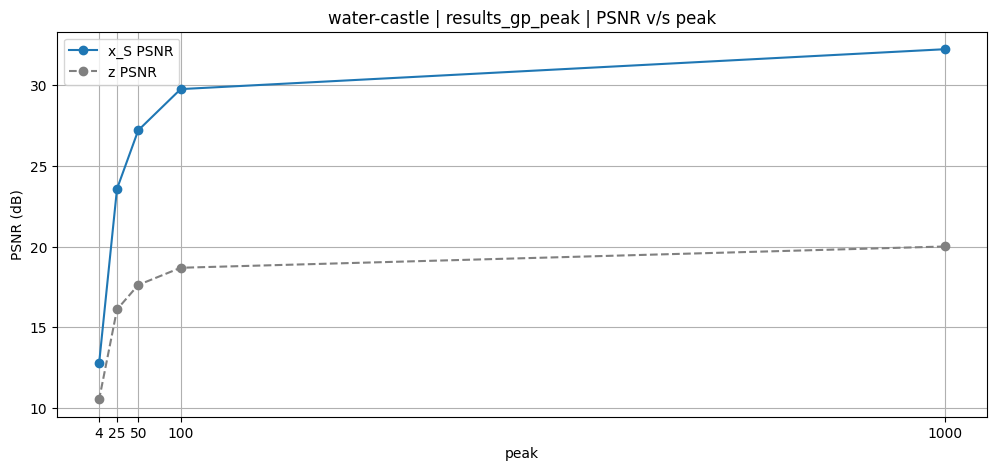

In [118]:
# Metrics for the same image and parameter values
for metric in ['psnr']: plot_noise_params(
        param='peak',
        param_values=peak_values_gp,
        x_metric_param=results_gp_peak[img_target]['x_' + metric],
        z_metric_param=results_gp_peak[img_target]['z_' + metric],
        metric=metric.upper(),
        title=img_target + ' | results_gp_peak'
    )


### $\sigma$ values, peak fixed

In [115]:
# test mixed noise values, peak fixed
peak_fixed = 100
sigma_values_gp = [5, 15, 25, 35, 50, 100]
results_gp_sigma = test_noise(vn_color, y, "gauss_poisson", sigma_values_gp, images_to_test, gp=False, peak_fixed=peak_fixed, scaled=False)

In [ ]:
# See results
img_target = 'water-castle'

for sigma in sigma_values_gp:
    z = results_gp_sigma[img_target]['images_by_param'][sigma]['z']
    x = results_gp_sigma[img_target]['images_by_param'][sigma]['x']
    y_result = results_gp_sigma[img_target]['images_by_param'][sigma]['y']
    plot_results(z, x, y_result, sigma=sigma, peak=peak_fixed, figsize=(16, 10))


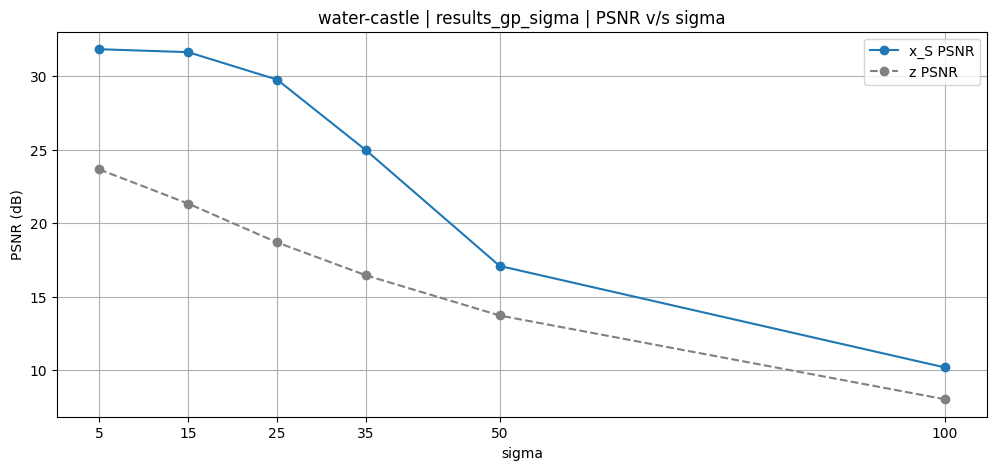

In [119]:
# Metrics for the same image and parameter values
for metric in ['psnr']: plot_noise_params(
        param='sigma',
        param_values=sigma_values_gp,
        x_metric_param=results_gp_sigma[img_target]['x_' + metric],
        z_metric_param=results_gp_sigma[img_target]['z_' + metric],
        metric=metric.upper(),
        title=img_target + ' | results_gp_sigma'
    )
